# WSB Top-200 - BMSB Buy-Readiness Screener

Applies the **Bull Market Support Band** strategy from `bmsb_strategy.ipynb` across the
**top 200 most-mentioned r/wallstreetbets tickers** (ApeWisdom), then **groups and ranks**
every name by how ready it is to buy *right now*.

For each ticker (weekly candles, 10y - the standard BMSB timeframe):
1. **Sweep** the same `W_GRID` parameter grid as the notebook.
2. Pick the **best config** with the notebook rule: keep 8-15 trade configs, rank by `Score = Total P&L x Win Rate`.
3. Evaluate the **live BUY/SELL/HOLD** signal on the latest bar.
4. Measure **proximity-to-trigger** and drop it into a bucket.

**Buckets**
- `BUY NOW` - fresh entry signal on the latest weekly bar (actionable).
- `CLOSE TO ENTERING` - flat but within ~6% of the trigger, or already in the anticipate buy-zone.
- `IN POSITION` - already trending above the band (strategy is holding); a new buyer is chasing.
- `SELL / EXIT` - strategy would be exiting.
- `WATCH` - flat and far from any trigger.

> **Research only, not financial advice.** Best-fit configs come from a parameter sweep and are partly curve-fit.

```bash
pip install -r requirements.txt
```

In [1]:
# ================= CONFIG - edit me =================
TOP_N     = 200        # how many WSB tickers to screen
PERIOD    = "10y"      # history length
INTERVAL  = "1wk"      # weekly = standard BMSB timeframe
NEAR_PCT  = 6.0        # within this % of the trigger => "close to entering"
OUTDIR    = "results"

# Weekly sweep grid - identical to W_GRID in bmsb_strategy.ipynb
#   (SMA lens, EMA lens, entry modes, RSI-buy thresholds, stop %, confirm bars)
W_GRID = ([15,20,25], [21,30,40], ["anticipate","breakout","reclaim"], [40,45,50], [0.08,0.12], [4,6])

In [2]:
import pandas as pd
from wsb_screener import screener as scr
from wsb_screener.data import get_wsb_tickers, download_history
from wsb_screener.screener import run_screener
from wsb_screener.report import build_markdown

# push notebook config into the screener module
scr.W_GRID   = W_GRID
scr.NEAR_PCT = NEAR_PCT
pd.set_option("display.max_rows", 250, "display.width", 240, "display.max_columns", 40)

## 1. Fetch the WSB universe + price history

In [3]:
tickers = get_wsb_tickers(TOP_N)
metas   = {t["ticker"]: t for t in tickers}
print(f"Top {len(metas)} r/wallstreetbets tickers by mention count")
print(", ".join(list(metas)[:25]), "...")

hist = download_history(list(metas), period=PERIOD, interval=INTERVAL)
print(f"\nDownloaded price data for {len(hist)}/{len(metas)} tickers")

Top 200 r/wallstreetbets tickers by mention count
MU, SPY, MSFT, WEN, SNDK, NVDA, TSLA, AMD, SPCX, META, QQQ, NBIS, RDDT, RKLB, MSTR, AAPL, DTE, HOOD, ASTS, NFLX, NOW, IP, IREN, AVGO, GOOG ...


$DS: possibly delisted; no price data found  (period=10y) (Yahoo error = "No data found, symbol may be delisted")


$OG: possibly delisted; no price data found  (period=10y) (Yahoo error = "No data found, symbol may be delisted")



2 Failed downloads:


['DS', 'OG']: possibly delisted; no price data found  (period=10y) (Yahoo error = "No data found, symbol may be delisted")


...

['RE']: possibly delisted; no price data found  (period=10y) (Yahoo error = "No data found, symbol may be delisted")


$DAY: possibly delisted; no price data found  (period=10y) (Yahoo error = "No data found, symbol may be delisted")



1 Failed download:


['DAY']: possibly delisted; no price data found  (period=10y) (Yahoo error = "No data found, symbol may be delisted")



Downloaded price data for 196/200 tickers


## 2. Screen everything (sweep -> best config -> live signal -> bucket)

In [4]:
df = run_screener(hist, metas)
signal_date = df["signal_date"].dropna().mode().iloc[0]
print("Latest weekly bar:", signal_date)
df["group"].value_counts()

  ...screened 25/200


  ...screened 50/200


  ...screened 75/200


  ...screened 100/200


  ...screened 125/200


  ...screened 150/200


  ...screened 175/200


  ...screened 200/200
Latest weekly bar: 2026-07-06


group
WATCH                80
IN POSITION          76
SELL / EXIT          18
CLOSE TO ENTERING    17
SKIPPED               5
BUY NOW               4
Name: count, dtype: int64

## 3. BUY NOW - fresh entry signals on the latest bar

In [5]:
cols = ["group_rank","ticker","name","close","readiness","recommendation","mode",
        "band_bot","band_top","rsi","need_move_%","bt_trades","bt_winrate_%","bt_pnl_$","bt_score"]
df[df.group=="BUY NOW"][cols]

,group_rank,ticker,name,close,readiness,recommendation,mode,band_bot,band_top,rsi,need_move_%,bt_trades,bt_winrate_%,bt_pnl_$,bt_score
0,1,NU,Nu Holdings,14.06,100.0,BUY (entry signal - act at next open),reclaim,13.70,14.25,49.4,-2.55,8.0,50.0,1635.75,817.9
1,2,OPEN,Opendoor,5.09,100.0,BUY (entry signal - act at next open),breakout,4.85,4.95,53.6,-2.75,8.0,37.5,957.47,359.1
2,3,TM,Toyota,179.93,100.0,BUY (entry signal - act at next open),anticipate,196.79,203.78,31.3,0.00,14.0,64.3,340.74,219.1
3,4,GOAT,VanEck Vectors ETF Trust - VanEck Vectors Morn...,38.58,100.0,BUY (entry signal - act at next open),reclaim,38.37,38.86,61.0,-0.54,14.0,42.9,249.99,107.2


## 4. CLOSE TO ENTERING - watch these this week

In [6]:
cols = ["group_rank","ticker","name","close","readiness","pos_vs_band","mode",
        "band_bot","band_top","rsi","need_move_%","note"]
df[df.group=="CLOSE TO ENTERING"][cols]

,group_rank,ticker,name,close,readiness,pos_vs_band,mode,band_bot,band_top,rsi,need_move_%,note
4,1,FANG,Diamondback Energy,173.73,80.0,below,anticipate,181.74,183.31,41.4,0.00,below band in RSI buy-zone; needs an up-close ...
5,2,META,Meta Platforms (Facebook),600.29,77.7,below,reclaim,618.14,618.22,53.5,2.97,3.0% below the band bottom; a close above it t...
6,3,ORCL,Oracle,143.79,75.0,below,anticipate,175.04,181.44,49.5,0.00,below band in RSI buy-zone; needs an up-close ...
7,4,XOM,Exxon Mobil,136.50,75.0,below,anticipate,143.04,148.06,34.5,0.00,below band in RSI buy-zone; needs an up-close ...
8,5,EU,enCore Energy,1.33,75.0,below,anticipate,1.61,1.76,36.5,0.00,below band in RSI buy-zone; needs an up-close ...
9,6,SLV,iShares Silver Trust,56.12,75.0,below,anticipate,60.41,68.58,38.1,0.00,below band in RSI buy-zone; needs an up-close ...
10,7,OKLO,Oklo,51.84,75.0,below,anticipate,60.34,62.75,52.7,0.00,below band in RSI buy-zone; needs an up-close ...
11,8,NVDA,NVIDIA,195.55,73.1,inside,breakout,193.51,202.88,58.0,3.75,3.8% below the band top; a close above it trig...
12,9,ASTS,AST SpaceMobile,80.64,70.0,below,anticipate,84.67,88.20,45.4,0.00,below band in RSI buy-zone; needs an up-close ...
13,10,CC,Chemours,18.19,70.0,below,anticipate,19.47,20.41,42.0,0.00,below band in RSI buy-zone; needs an up-close ...


## 5. IN POSITION (riding) / SELL / WATCH

In [7]:
pcols = ["group_rank","ticker","name","close","recommendation","mode","band_bot","band_top","rsi","need_move_%","bt_winrate_%","bt_score"]
display(df[df.group=="IN POSITION"][pcols].head(25))
display(df[df.group=="SELL / EXIT"][pcols])
wcols = ["group_rank","ticker","name","close","readiness","pos_vs_band","mode","band_bot","band_top","rsi","need_move_%"]
display(df[df.group=="WATCH"][wcols].head(25))

,group_rank,ticker,name,close,recommendation,mode,band_bot,band_top,rsi,need_move_%,bt_winrate_%,bt_score
21,1,SNDK,Sandisk,1744.43,HOLD (in position - riding the move),breakout,980.42,1262.45,70.8,-27.63,50.0,19689.0
22,2,SOXL,Direxion Shares ETF Trust - Direxion Daily Sem...,194.77,HOLD (in position - riding the move),anticipate,115.09,139.30,65.9,-40.91,53.3,9681.0
23,3,LITE,Lumentum,731.25,HOLD (in position - riding the move),anticipate,623.15,753.70,42.6,-14.78,63.6,8791.1
24,4,MU,Micron Technology,984.75,HOLD (in position - riding the move),anticipate,735.77,769.77,75.9,-25.28,58.3,7265.8
25,5,WDC,Western Digital,577.46,HOLD (in position - riding the move),anticipate,400.11,401.89,69.2,-30.71,50.0,7134.7
26,6,STX,Seagate Technology,868.26,HOLD (in position - riding the move),anticipate,617.66,704.51,71.9,-28.86,61.5,6892.6
27,7,NVTS,Navitas Semiconductor,15.23,HOLD (in position - riding the move),anticipate,13.87,14.73,58.6,-8.91,54.5,4607.6
28,8,DELL,Dell,411.51,HOLD (in position - riding the move),anticipate,258.55,306.44,82.1,-37.17,69.2,4519.4
29,9,WULF,TeraWulf,22.21,HOLD (in position - riding the move),breakout,19.33,19.43,62.4,-12.52,50.0,3785.0
30,10,TQQQ,ProShares Trust - ProShares UltraPro QQQ,76.42,HOLD (in position - riding the move),breakout,63.34,63.63,70.7,-16.74,80.0,3589.9


,group_rank,ticker,name,close,recommendation,mode,band_bot,band_top,rsi,need_move_%,bt_winrate_%,bt_score
97,1,IT,Gartner,135.11,SELL (lost the band),anticipate,151.80,194.84,40.7,0.00,60.0,371.5
98,2,AB,AllianceBernstein,36.68,SELL (lost the band),anticipate,37.23,37.37,41.7,0.00,85.7,2251.6
99,3,DJT,Trump Media & Technology Group,8.66,SELL (lost the band),anticipate,8.77,10.35,47.2,0.00,46.7,784.6
100,4,BMNR,Bitmine Immersion Technologies,15.54,SELL (lost the band),anticipate,18.63,22.92,38.3,0.00,25.0,-125.8
101,5,MCD,McDonald,279.47,SELL (lost the band),anticipate,286.46,294.04,33.7,0.00,69.2,657.2
102,6,PEP,Pepsico,143.29,SELL (lost the band),anticipate,147.18,148.39,30.2,0.00,60.0,408.2
103,7,UBER,Uber,72.43,SELL (lost the band),anticipate,73.77,77.10,51.0,0.00,46.7,684.5
104,8,GLD,SSgA SPDR Gold Shares,382.06,SELL (lost the band),anticipate,406.41,420.04,31.2,0.00,61.5,870.5
105,9,BSX,Boston Scientific,44.60,SELL (lost the band),anticipate,52.99,64.34,24.4,0.00,66.7,187.2
106,10,QXO,"QXO, Inc.",15.80,SELL (lost the band),anticipate,19.55,20.04,42.3,0.00,40.0,-207.9


,group_rank,ticker,name,close,readiness,pos_vs_band,mode,band_bot,band_top,rsi,need_move_%
115,1,MSTR,MicroStrategy,100.77,45.0,below,anticipate,139.20,172.08,45.2,0.00
116,2,IREN,Iris Energy,43.91,45.0,below,anticipate,47.63,48.68,54.7,0.00
117,3,ONDS,Ondas Holdings,7.82,45.0,below,anticipate,9.07,9.63,44.7,0.00
118,4,CMG,Chipotle Mexican Grill,33.99,45.0,below,anticipate,34.37,36.24,52.4,0.00
119,5,MP,MP Materials,53.00,45.0,below,anticipate,58.29,58.44,53.5,0.00
120,6,LUNR,Intuitive Machines,18.89,45.0,below,anticipate,23.82,27.22,44.9,0.00
121,7,AVAV,AeroVironment,176.84,45.0,below,anticipate,178.42,195.62,48.5,0.00
122,8,HBM,Hudbay Minerals,23.35,45.0,below,anticipate,23.85,24.85,53.2,0.00
123,9,SA,Seabridge Gold,27.40,45.0,below,anticipate,29.18,30.03,45.6,0.00
124,10,PUMP,ProPetro,12.28,45.0,below,anticipate,13.85,14.99,43.9,0.00


## 6. Save CSV + Markdown report

In [8]:
import os
os.makedirs(OUTDIR, exist_ok=True)
df.to_csv(f"{OUTDIR}/wsb_bmsb_screen.csv", index=False)
with open(f"{OUTDIR}/wsb_bmsb_report.md", "w") as f:
    f.write(build_markdown(df, len(metas), signal_date))
print("wrote", f"{OUTDIR}/wsb_bmsb_screen.csv", "and", f"{OUTDIR}/wsb_bmsb_report.md")

wrote results/wsb_bmsb_screen.csv and results/wsb_bmsb_report.md


## 7. (Optional) Drill into one ticker's BMSB chart
Reuses the exact backtest/plot from `bmsb_strategy.ipynb` for any symbol in the table.

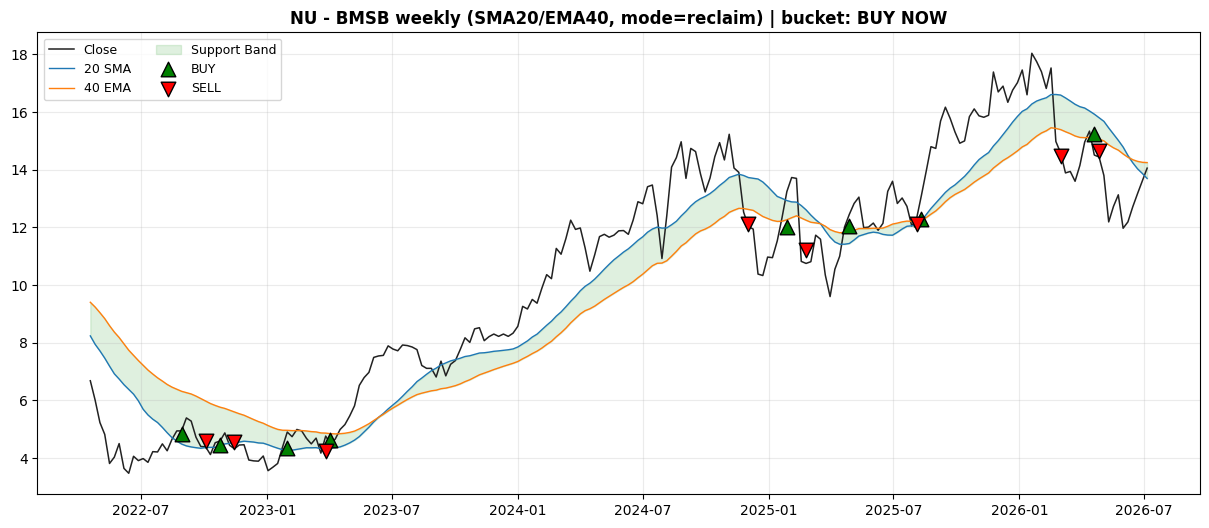

{'Total Trades': 8, 'Win Rate %': 50.0, 'Total P&L $': np.float64(1635.75), 'Avg Win $': np.float64(453.95), 'Avg Loss $': np.float64(-45.02), 'Profit Factor': np.float64(10.08), 'Expectancy $': np.float64(204.47), 'Avg Bars Held': np.float64(18.9), 'Max Drawdown $': np.float64(-66.19), 'Return/Trade %': np.float64(20.45)}


In [9]:
%matplotlib inline
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from wsb_screener.bmsb_core import bmsb_backtest, compute_stats

SYMBOL = "NU"   # <- pick any ticker from the tables above
row = df[df.ticker==SYMBOL].iloc[0]
d, t = bmsb_backtest(hist[SYMBOL], int(row.sma), int(row.ema), row['mode'], int(row.rsi_buy), float(row.stop), int(row.cbars))

fig, ax = plt.subplots(figsize=(15,6))
ax.plot(d.Date, d.Close, color="#222", lw=1.1, label="Close")
ax.plot(d.Date, d.SMA, color="#1f77b4", lw=1.0, label=f"{int(row.sma)} SMA")
ax.plot(d.Date, d.EMA, color="#ff7f0e", lw=1.0, label=f"{int(row.ema)} EMA")
ax.fill_between(d.Date, d.band_bot, d.band_top, color="#2ca02c", alpha=0.15, label="Support Band")
if not t.empty:
    ax.scatter(t.entry_date, t.entry_price, marker="^", s=110, color="green", edgecolor="k", zorder=5, label="BUY")
    ax.scatter(t.exit_date,  t.exit_price,  marker="v", s=110, color="red",   edgecolor="k", zorder=5, label="SELL")
ax.set_title(f"{SYMBOL} - BMSB weekly (SMA{int(row.sma)}/EMA{int(row.ema)}, mode={row['mode']}) | bucket: {row.group}", weight="bold")
ax.legend(loc="upper left", ncol=2, fontsize=9); ax.grid(alpha=0.25)
plt.show()
print(compute_stats(t))